# Spectral-cover monodromy for irregular Class S punctures

This notebook implements the numerical spectral-cover monodromy computation used in https://arxiv.org/abs/2201.00018

Steps:

1. represent the local Seiberg--Witten geometry near a puncture as a polynomial spectral curve
   \[
   F(v,t)=0, \qquad \lambda = v\,dt/t,
   \]
2. compute the sheets \(v_i(t_0)\) at a reference point \(t_0\),
3. label sheets by weights of the relevant ADE representation,
4. drag \(t_0\) around a **small** loop linking the puncture and track the sheet permutation,
5. convert the induced weight permutation to a matrix on the root lattice, and
6. compute \(\mathrm{Tor}\,\mathrm{coker}(M_P-1)\) by Smith normal form.


## Mathematical conventions

- The curve is local around \(t=0\). The loop used for monodromy must be small enough to avoid branch points not associated with the puncture. The helper `choose_local_radius` shrinks the loop and asks for stabilization of the computed permutation.
- Matrices act on simple roots by columns: column \(j\) is the image of \(\alpha_j\) in the simple-root basis.
- Finite abelian groups are represented as invariant factors. For instance `[3, 3]` denotes \(\mathbb Z_3^2\), while `[]` denotes the trivial group.
- For E6, the notebook labels sheets by matching the vanishing-triplet hypergraph of the 27 sheets to the vanishing-triplet hypergraph of the 27 weights. For E7, it uses the analogous pair/quadruplet incidence structure of the 56 weights. This is the Python version of the hand-labelling used in Section 10.2.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from fractions import Fraction
from itertools import combinations
from collections import deque
from typing import Callable, Iterable, Optional, Sequence

import math
import numpy as np
import pandas as pd
import sympy as sp
from scipy.optimize import linear_sum_assignment
from sympy.matrices.normalforms import smith_normal_form

try:
    import networkx as nx
except ImportError as exc:  # pragma: no cover
    raise ImportError("networkx is required for E6 hypergraph sheet labelling") from exc

import matplotlib.pyplot as plt

## 1. Spectral curves, sheet locations, and monodromy tracking

A `PolynomialCurve` is a local spectral curve in the variable `v`; its coefficients are functions of the base coordinate `t`. The convention is the same as `numpy.roots`: coefficients are returned from highest power of `v` down to the constant term.

In [2]:
@dataclass(frozen=True)
class PolynomialCurve:
    """A local spectral curve F(v,t)=0 with polynomial dependence on v.

    Parameters
    ----------
    coeffs:
        Function of complex t returning coefficients of F(v,t), highest power first.
    name:
        Human-readable name used in output tables and plots.
    """

    coeffs: Callable[[complex], Sequence[complex]]
    name: str = "spectral curve"

    def coefficients(self, t: complex) -> np.ndarray:
        c = np.asarray(self.coeffs(complex(t)), dtype=np.complex128)
        if c.ndim != 1 or len(c) < 2:
            raise ValueError("coeffs(t) must return a one-dimensional coefficient vector")
        # Trim numerically zero leading coefficients. This keeps numpy.roots stable when
        # a deformation switches off the top term in a special limit.
        idx = 0
        while idx < len(c) - 1 and abs(c[idx]) < 1e-14:
            idx += 1
        return c[idx:]

    def roots(self, t: complex) -> np.ndarray:
        return np.roots(self.coefficients(t))


def pairwise_min_separation(values: np.ndarray) -> float:
    """Minimum pairwise distance in a set of complex numbers."""
    values = np.asarray(values)
    if len(values) < 2:
        return float("inf")
    diffs = np.abs(values[:, None] - values[None, :])
    diffs[diffs == 0] = np.inf
    return float(np.min(diffs))


@dataclass
class TrackingResult:
    curve: PolynomialCurve
    radius: float
    center: complex
    start_t: complex
    path: np.ndarray
    roots0: np.ndarray
    trajectories: np.ndarray
    permutation: np.ndarray
    max_step_displacement: float
    final_matching_error: float
    min_separation: float

    @property
    def cycles(self) -> list[list[int]]:
        return cycle_decomposition(self.permutation)


def track_sheets_along_path(curve: PolynomialCurve, path: Sequence[complex]) -> TrackingResult:
    """Track roots of F(v,t)=0 along a path in the t-plane.

    The matching between consecutive time-slices is solved by the Hungarian algorithm.
    The order of rows in `trajectories` is fixed by the initial sheet order: trajectory[j,k]
    is the location at step j of the sheet that started as roots0[k].
    """
    path = np.asarray(path, dtype=np.complex128)
    if len(path) < 2:
        raise ValueError("path must contain at least two points")

    roots0 = curve.roots(path[0])
    n = len(roots0)
    current = roots0.copy()
    trajectories = [current.copy()]
    max_step = 0.0
    min_sep = pairwise_min_separation(current)

    for t in path[1:]:
        nxt = curve.roots(t)
        if len(nxt) != n:
            raise ValueError("degree changed along the path")
        cost = np.abs(current[:, None] - nxt[None, :])
        rows, cols = linear_sum_assignment(cost)
        matched = np.empty_like(current)
        for row, col in zip(rows, cols):
            matched[row] = nxt[col]
        max_step = max(max_step, float(np.max(np.abs(matched - current))))
        min_sep = min(min_sep, pairwise_min_separation(matched))
        current = matched
        trajectories.append(current.copy())

    # Close the loop: where did each initial sheet land?
    closing_cost = np.abs(current[:, None] - roots0[None, :])
    rows, cols = linear_sum_assignment(closing_cost)
    perm = np.empty(n, dtype=int)
    for row, col in zip(rows, cols):
        perm[row] = col

    return TrackingResult(
        curve=curve,
        radius=float(abs(path[0] - (0 + 0j))),
        center=0 + 0j,
        start_t=path[0],
        path=path,
        roots0=roots0,
        trajectories=np.asarray(trajectories),
        permutation=perm,
        max_step_displacement=max_step,
        final_matching_error=float(np.max(closing_cost[rows, cols])),
        min_separation=min_sep,
    )


def monodromy_permutation(
    curve: PolynomialCurve,
    radius: float,
    *,
    center: complex = 0.0 + 0.0j,
    steps: int = 720,
) -> TrackingResult:
    """Track sheets around a circle centered at the puncture."""
    theta = np.linspace(0.0, 2.0 * np.pi, steps + 1)
    path = center + radius * np.exp(1j * theta)
    result = track_sheets_along_path(curve, path)
    result.radius = radius
    result.center = center
    return result


def choose_local_radius(
    curve: PolynomialCurve,
    *,
    initial_radius: float = 1.0,
    shrink: float = 0.5,
    min_radius: float = 1e-4,
    steps: int = 720,
    required_stable_rounds: int = 1,
    min_separation_tol: float = 1e-8,
    verbose: bool = False,
) -> TrackingResult:
    """Choose a small loop that isolates the puncture monodromy.

    The routine scans a nested sequence of loops and returns the smallest stable
    permutation it sees. This matters: a large loop may accidentally enclose additional
    branch points and give a different, often even trivial, net monodromy.
    """
    previous_signature: Optional[tuple[int, ...]] = None
    stable_rounds = 0
    radius = initial_radius
    best: Optional[TrackingResult] = None

    while radius >= min_radius:
        current = monodromy_permutation(curve, radius, steps=steps)
        signature = tuple(sorted([len(c) for c in current.cycles]))
        if verbose:
            print(
                f"r={radius:.3e}, cycles={list(signature)}, "
                f"min_sep={current.min_separation:.3e}, close_err={current.final_matching_error:.3e}"
            )
        if previous_signature is not None and signature == previous_signature:
            stable_rounds += 1
        else:
            stable_rounds = 0
        if stable_rounds >= required_stable_rounds and current.min_separation > min_separation_tol:
            best = current
        previous_signature = signature
        radius *= shrink

    if best is not None:
        return best
    raise RuntimeError(
        "No stable local radius found. Try increasing steps, changing initial_radius, "
        "or adding a generic deformation that separates colliding sheets."
    )


def cycle_decomposition(perm: Sequence[int], *, one_indexed: bool = False) -> list[list[int]]:
    """Cycle decomposition of a permutation p where i maps to p[i]."""
    perm = list(map(int, perm))
    seen = set()
    cycles = []
    shift = 1 if one_indexed else 0
    for i in range(len(perm)):
        if i in seen:
            continue
        cyc = []
        j = i
        while j not in seen:
            seen.add(j)
            cyc.append(j + shift)
            j = perm[j]
        if len(cyc) > 1:
            cycles.append(cyc)
    return cycles


def permutation_summary(perm: Sequence[int]) -> str:
    cycles = cycle_decomposition(perm, one_indexed=True)
    if not cycles:
        return "identity"
    return " ".join("(" + " ".join(map(str, cyc)) + ")" for cyc in cycles)

## 2. ADE weight systems and the root-lattice matrix

The spectral-cover permutation acts on sheets; after labelling sheets by weights, it acts on the weight lattice. The function `root_matrix_from_weight_permutation` restricts that action to the root lattice.

In [3]:
def _Q(x) -> sp.Rational:
    if isinstance(x, Fraction):
        return sp.Rational(x.numerator, x.denominator)
    return sp.Rational(x)


@dataclass(frozen=True)
class WeightSystem:
    name: str
    weights: sp.Matrix                  # rows are weights in an ambient vector space
    simple_roots: sp.Matrix             # rows are simple roots in the same ambient space
    simple_root_weight_expr: sp.Matrix  # row j expresses alpha_j as a linear combination of weights

    @property
    def rank(self) -> int:
        return int(self.simple_roots.rows)

    @property
    def n_weights(self) -> int:
        return int(self.weights.rows)


def A_weight_system(n: int) -> WeightSystem:
    """Weights of the fundamental of A_{n-1}."""
    if n < 2:
        raise ValueError("A_{n-1} requires n>=2")
    weights = sp.eye(n)
    simple_roots = []
    expr = sp.zeros(n - 1, n)
    for i in range(n - 1):
        row = [0] * n
        row[i] = 1
        row[i + 1] = -1
        simple_roots.append(row)
        expr[i, i] = 1
        expr[i, i + 1] = -1
    return WeightSystem(f"A_{n-1} fundamental", weights, sp.Matrix(simple_roots), expr)


def D_weight_system(n: int) -> WeightSystem:
    """Weights of the vector representation of D_n."""
    if n < 4:
        raise ValueError("D_n vector representation is used here for n>=4")
    weights = []
    for i in range(n):
        row = [0] * n
        row[i] = 1
        weights.append(row)
    for i in range(n):
        row = [0] * n
        row[i] = -1
        weights.append(row)

    simple_roots = []
    expr = sp.zeros(n, 2 * n)
    for i in range(n - 1):
        row = [0] * n
        row[i] = 1
        row[i + 1] = -1
        simple_roots.append(row)
        expr[i, i] = 1
        expr[i, i + 1] = -1
    row = [0] * n
    row[n - 2] = 1
    row[n - 1] = 1
    simple_roots.append(row)
    expr[n - 1, n - 2] = 1       # e_{n-1}
    expr[n - 1, 2 * n - 1] = -1 # -(-e_n)
    return WeightSystem(f"D_{n} vector", sp.Matrix(weights), sp.Matrix(simple_roots), expr)


def E6_weight_system() -> WeightSystem:
    """The 27 weights and simple roots in the E8 ambient coordinates used in the paper."""
    F = Fraction
    weights_raw = [
        (0, 0, 0, 0, 0, F(-2, 3), F(-2, 3), F(2, 3)),
        (F(-1, 2), F(1, 2), F(1, 2), F(1, 2), F(1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (F(1, 2), F(-1, 2), F(1, 2), F(1, 2), F(1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (F(1, 2), F(1, 2), F(-1, 2), F(1, 2), F(1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (F(-1, 2), F(-1, 2), F(-1, 2), F(1, 2), F(1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (F(1, 2), F(1, 2), F(1, 2), F(-1, 2), F(1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (F(1, 2), F(1, 2), F(1, 2), F(1, 2), F(-1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (F(-1, 2), F(-1, 2), F(1, 2), F(1, 2), F(-1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (F(-1, 2), F(1, 2), F(-1, 2), F(-1, 2), F(1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (F(-1, 2), F(-1, 2), F(1, 2), F(-1, 2), F(1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (F(-1, 2), F(1, 2), F(-1, 2), F(1, 2), F(-1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (F(1, 2), F(-1, 2), F(-1, 2), F(-1, 2), F(1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (0, 0, 0, 1, 0, F(1, 3), F(1, 3), F(-1, 3)),
        (0, 0, 0, 0, 1, F(1, 3), F(1, 3), F(-1, 3)),
        (F(1, 2), F(-1, 2), F(-1, 2), F(1, 2), F(-1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (F(-1, 2), F(1, 2), F(1, 2), F(-1, 2), F(-1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (0, 0, 1, 0, 0, F(1, 3), F(1, 3), F(-1, 3)),
        (F(1, 2), F(1, 2), F(-1, 2), F(-1, 2), F(-1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (F(1, 2), F(-1, 2), F(1, 2), F(-1, 2), F(-1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (0, 1, 0, 0, 0, F(1, 3), F(1, 3), F(-1, 3)),
        (F(-1, 2), F(-1, 2), F(-1, 2), F(-1, 2), F(-1, 2), F(-1, 6), F(-1, 6), F(1, 6)),
        (-1, 0, 0, 0, 0, F(1, 3), F(1, 3), F(-1, 3)),
        (1, 0, 0, 0, 0, F(1, 3), F(1, 3), F(-1, 3)),
        (0, -1, 0, 0, 0, F(1, 3), F(1, 3), F(-1, 3)),
        (0, 0, -1, 0, 0, F(1, 3), F(1, 3), F(-1, 3)),
        (0, 0, 0, -1, 0, F(1, 3), F(1, 3), F(-1, 3)),
        (0, 0, 0, 0, -1, F(1, 3), F(1, 3), F(-1, 3)),
    ]
    roots_raw = [
        (F(1, 2), F(-1, 2), F(-1, 2), F(-1, 2), F(-1, 2), F(-1, 2), F(-1, 2), F(1, 2)),
        (1, 1, 0, 0, 0, 0, 0, 0),
        (-1, 1, 0, 0, 0, 0, 0, 0),
        (0, -1, 1, 0, 0, 0, 0, 0),
        (0, 0, -1, 1, 0, 0, 0, 0),
        (0, 0, 0, -1, 1, 0, 0, 0),
    ]
    weights = sp.Matrix([[_Q(x) for x in row] for row in weights_raw])
    roots = sp.Matrix([[_Q(x) for x in row] for row in roots_raw])

    # Table 14 expresses alpha_1 as a rational combination of weights; the remaining
    # simple roots are weight differences.
    expr = sp.zeros(6, 27)
    expr[0, 21] = sp.Rational(-2)       # -2 w22
    expr[0, 22] = sp.Rational(-3, 2)    # -3/2 w23
    for idx in [23, 24, 25, 26]:
        expr[0, idx] = sp.Rational(1, 2)
    expr[1, 22] = 1; expr[1, 23] = -1   # w23 - w24
    expr[2, 21] = 1; expr[2, 23] = -1   # w22 - w24
    expr[3, 23] = 1; expr[3, 24] = -1   # w24 - w25
    expr[4, 24] = 1; expr[4, 25] = -1   # w25 - w26
    expr[5, 25] = 1; expr[5, 26] = -1   # w26 - w27
    return WeightSystem("E6 27", weights, roots, expr)



def E7_cartan() -> sp.Matrix:
    """Cartan matrix in the E7 numbering used for the precomputed monodromies."""
    A = 2 * sp.eye(7)
    for i, j in [(0, 2), (2, 3), (3, 4), (4, 5), (5, 6), (1, 3)]:
        A[i, j] = A[j, i] = -1
    return A


def minuscule_weight_system_from_cartan(A: sp.Matrix, highest_node: int, name: str) -> WeightSystem:
    """Generate a minuscule weight system in Dynkin-label coordinates.

    If a weight has positive Dynkin label in direction i, lowering by alpha_i gives
    another weight. This closes on the Weyl orbit for minuscule representations.
    """
    rank = A.rows
    highest = [0] * rank
    highest[highest_node] = 1
    seen = {tuple(highest)}
    queue = deque([tuple(highest)])
    while queue:
        mu = queue.popleft()
        for i in range(rank):
            if mu[i] > 0:
                nu = list(mu)
                for j in range(rank):
                    nu[j] -= int(A[j, i])
                nu = tuple(nu)
                if nu not in seen:
                    seen.add(nu)
                    queue.append(nu)
    weights_list = sorted(seen)
    weights = sp.Matrix(weights_list)
    simple_roots = sp.Matrix([[int(A[j, i]) for j in range(rank)] for i in range(rank)])

    expr = sp.zeros(rank, len(weights_list))
    for i in range(rank):
        target = tuple(simple_roots[i, j] for j in range(rank))
        found = False
        for a, wa in enumerate(weights_list):
            for b, wb in enumerate(weights_list):
                if tuple(wa[j] - wb[j] for j in range(rank)) == target:
                    expr[i, a] = 1
                    expr[i, b] = -1
                    found = True
                    break
            if found:
                break
        if not found:
            raise RuntimeError(f"could not express simple root {i+1} as a weight difference")
    return WeightSystem(name, weights, simple_roots, expr)


def E7_weight_system() -> WeightSystem:
    """The 56 weights of the minuscule E7 representation in Dynkin-label coordinates."""
    return minuscule_weight_system_from_cartan(E7_cartan(), highest_node=6, name="E7 56")


def root_matrix_from_weight_permutation(ws: WeightSystem, weight_perm: Sequence[int]) -> sp.Matrix:
    """Convert a permutation of weights to its action on the simple-root lattice."""
    weight_perm = list(map(int, weight_perm))
    if len(weight_perm) != ws.n_weights or sorted(weight_perm) != list(range(ws.n_weights)):
        raise ValueError("weight_perm must be a permutation of all weights")

    ambient_to_roots = ws.simple_roots.T
    M = sp.zeros(ws.rank, ws.rank)
    for j in range(ws.rank):
        image = sp.zeros(ws.weights.cols, 1)
        for a in range(ws.n_weights):
            coeff = ws.simple_root_weight_expr[j, a]
            if coeff:
                image += coeff * ws.weights[weight_perm[a], :].T
        coeffs = ambient_to_roots.gauss_jordan_solve(image)[0]
        for i in range(ws.rank):
            val = sp.simplify(coeffs[i])
            if val.q != 1:
                raise ValueError(f"non-integral root coefficient {val} in image of alpha_{j+1}")
            M[i, j] = int(val)
    return M


def smith_invariant_factors(matrix: sp.Matrix) -> list[int]:
    """Invariant factors of Tor coker(matrix)."""
    D = smith_normal_form(sp.Matrix(matrix), domain=sp.ZZ)
    factors = []
    for i in range(min(D.rows, D.cols)):
        d = abs(int(D[i, i]))
        if d > 1:
            factors.append(d)
    return factors


def defect_group_from_monodromy(M: sp.Matrix) -> list[int]:
    """Compute Tor coker(M-I) from a root-lattice monodromy matrix."""
    return smith_invariant_factors(sp.Matrix(M) - sp.eye(M.rows))


def group_str(factors: Sequence[int]) -> str:
    """Pretty-print a finite abelian group from invariant factors."""
    factors = list(map(int, factors))
    if not factors:
        return "0"
    parts = []
    for d in sorted(set(factors)):
        m = factors.count(d)
        parts.append(f"Z{d}" if m == 1 else f"Z{d}^{m}")
    return " × ".join(parts)


def subtract_group_factors(big: Sequence[int], small: Sequence[int]) -> list[int]:
    """Multiset subtraction for split products of cyclic factors."""
    remaining = list(big)
    for x in small:
        if x not in remaining:
            raise ValueError(f"cannot subtract factor {x} from {big}")
        remaining.remove(x)
    return sorted(remaining)


def square_root_group_factors(factors: Sequence[int]) -> list[int]:
    """Return G when factors represent G x G in the examples below."""
    out = []
    for d in sorted(set(factors)):
        m = list(factors).count(d)
        if m % 2:
            raise ValueError(f"{factors} is not a square product")
        out.extend([d] * (m // 2))
    return out

## 3. Labelling sheets by weights

The numerical root order returned by `numpy.roots` is arbitrary. For classical groups the labelling is simple: any ordering works for the fundamental of A, while for D we first pair roots related by \(v\mapsto -v\). For E6 the labelling is reconstructed from the 45 vanishing triples.

In [4]:
def label_A_sheets(roots: np.ndarray) -> list[int]:
    """Assign roots to fundamental weights of A by a deterministic angular order."""
    order = sorted(range(len(roots)), key=lambda i: (np.angle(roots[i]), abs(roots[i])))
    sheet_to_weight = [None] * len(roots)
    for weight_idx, sheet_idx in enumerate(order):
        sheet_to_weight[sheet_idx] = weight_idx
    return sheet_to_weight


def label_D_sheets_by_pairs(roots: np.ndarray, n: int, *, tol: float = 1e-6) -> list[int]:
    """Label 2n sheets by the vector weights +e_i, -e_i of D_n.

    The curve should be invariant under v -> -v. We pair sheets with nearly opposite
    v-values and assign the pair to (+e_i, -e_i). The order of pairs is arbitrary up to
    Weyl/diagram automorphism and does not affect the computed invariant factors.
    """
    if len(roots) != 2 * n:
        raise ValueError(f"expected {2*n} roots for D_{n}, got {len(roots)}")
    unused = set(range(2 * n))
    pairs = []
    while unused:
        i = min(unused)
        unused.remove(i)
        j = min(unused, key=lambda k: abs(roots[i] + roots[k]))
        if abs(roots[i] + roots[j]) > tol:
            raise ValueError("could not pair D_n sheets by v -> -v; try a larger tolerance")
        unused.remove(j)
        # Choose a deterministic sign convention within the pair.
        if (np.angle(roots[i]), abs(roots[i])) <= (np.angle(roots[j]), abs(roots[j])):
            pairs.append((i, j))
        else:
            pairs.append((j, i))
    pairs.sort(key=lambda ij: (np.angle(roots[ij[0]]), abs(roots[ij[0]])))
    sheet_to_weight = [None] * (2 * n)
    for a, (plus_sheet, minus_sheet) in enumerate(pairs):
        sheet_to_weight[plus_sheet] = a
        sheet_to_weight[minus_sheet] = n + a
    return sheet_to_weight


def _zero_sum_hyperedges_exact(weights: sp.Matrix, size: int) -> list[tuple[int, ...]]:
    edges = []
    for comb in combinations(range(weights.rows), size):
        total = [sum(weights[i, j] for i in comb) for j in range(weights.cols)]
        if all(x == 0 for x in total):
            edges.append(tuple(comb))
    return edges


def _zero_sum_hyperedges_numeric(values: Sequence[complex], size: int, tol: float) -> list[tuple[int, ...]]:
    values = np.asarray(values, dtype=np.complex128)
    edges = []
    for comb in combinations(range(len(values)), size):
        if abs(sum(values[i] for i in comb)) < tol:
            edges.append(tuple(comb))
    return edges


def _incidence_graph(n_vertices: int, hyperedges: Sequence[tuple[int, ...]], prefix: str) -> nx.Graph:
    G = nx.Graph()
    for i in range(n_vertices):
        G.add_node((prefix, "v", i), kind="v")
    for h, edge in enumerate(hyperedges):
        hnode = (prefix, "h", h)
        G.add_node(hnode, kind="h", size=len(edge))
        for i in edge:
            G.add_edge(hnode, (prefix, "v", i))
    return G


def label_E6_sheets_by_triplets(roots: np.ndarray, ws: WeightSystem, *, tol: float = 1e-6) -> list[int]:
    """Label E6 sheets by matching numerical and weight vanishing-triplet hypergraphs."""
    if ws.name != "E6 27":
        raise ValueError("this helper expects the E6 27 weight system")
    if len(roots) != 27:
        raise ValueError("E6 27 curve should have 27 sheets")

    sheet_triples = _zero_sum_hyperedges_numeric(roots, 3, tol)
    weight_triples = _zero_sum_hyperedges_exact(ws.weights, 3)
    if len(sheet_triples) != 45:
        raise ValueError(f"expected 45 numerical vanishing triples, found {len(sheet_triples)}")
    if len(weight_triples) != 45:
        raise ValueError(f"expected 45 weight vanishing triples, found {len(weight_triples)}")

    Gs = _incidence_graph(27, sheet_triples, "sheet")
    Gw = _incidence_graph(27, weight_triples, "weight")
    node_match = nx.algorithms.isomorphism.categorical_node_match(["kind", "size"], [None, None])
    matcher = nx.algorithms.isomorphism.GraphMatcher(Gs, Gw, node_match=node_match)
    if not matcher.is_isomorphic():
        raise RuntimeError("could not match E6 sheet and weight hypergraphs")
    mapping = matcher.mapping
    return [mapping[("sheet", "v", i)][2] for i in range(27)]



def _weight_zero_pairs_and_quads(ws: WeightSystem) -> tuple[list[tuple[int, int]], list[tuple[int, int, int, int]]]:
    """Zero pairs and zero quadruplets for the E7 56 incidence structure."""
    pairs = []
    for comb in combinations(range(ws.n_weights), 2):
        if all(ws.weights[comb[0], j] + ws.weights[comb[1], j] == 0 for j in range(ws.weights.cols)):
            pairs.append(tuple(comb))
    pair_set = {frozenset(p) for p in pairs}
    quads = []
    for comb in combinations(range(ws.n_weights), 4):
        if all(sum(ws.weights[i, j] for i in comb) == 0 for j in range(ws.weights.cols)):
            if not any(frozenset(p) in pair_set for p in combinations(comb, 2)):
                quads.append(tuple(comb))
    return pairs, quads


def _numeric_zero_pairs_and_quads(values: Sequence[complex], tol: float) -> tuple[list[tuple[int, int]], list[tuple[int, int, int, int]]]:
    values = np.asarray(values, dtype=np.complex128)
    pairs = []
    for comb in combinations(range(len(values)), 2):
        if abs(values[comb[0]] + values[comb[1]]) < tol:
            pairs.append(tuple(comb))
    pair_set = {frozenset(p) for p in pairs}
    quads = []
    for comb in combinations(range(len(values)), 4):
        if abs(sum(values[i] for i in comb)) < tol:
            if not any(frozenset(p) in pair_set for p in combinations(comb, 2)):
                quads.append(tuple(comb))
    return pairs, quads


def _mixed_incidence_graph(n_vertices: int, pairs: Sequence[tuple[int, int]], quads: Sequence[tuple[int, int, int, int]], prefix: str) -> nx.Graph:
    G = nx.Graph()
    for i in range(n_vertices):
        G.add_node((prefix, "v", i), kind="v", size=0)
    for h, edge in enumerate(pairs):
        node = (prefix, "p", h)
        G.add_node(node, kind="h", size=2)
        for i in edge:
            G.add_edge(node, (prefix, "v", i))
    for h, edge in enumerate(quads):
        node = (prefix, "q", h)
        G.add_node(node, kind="h", size=4)
        for i in edge:
            G.add_edge(node, (prefix, "v", i))
    return G


def label_E7_sheets_by_incidence(roots: np.ndarray, ws: WeightSystem, *, tol: float = 1e-6) -> list[int]:
    """Label E7 sheets by matching the 28 pair and 630 quadruplet incidence structure.

    This is heavier than the E6 triplet matching, but it is still practical for one-off
    numerical labelling of a 56-sheet spectral cover.
    """
    if ws.name != "E7 56":
        raise ValueError("this helper expects the E7 56 weight system")
    if len(roots) != 56:
        raise ValueError("E7 56 curve should have 56 sheets")
    sheet_pairs, sheet_quads = _numeric_zero_pairs_and_quads(roots, tol)
    weight_pairs, weight_quads = _weight_zero_pairs_and_quads(ws)
    if len(sheet_pairs) != 28 or len(sheet_quads) != 630:
        raise ValueError(f"expected 28 pairs and 630 quadruplets; found {len(sheet_pairs)} and {len(sheet_quads)}")
    Gs = _mixed_incidence_graph(56, sheet_pairs, sheet_quads, "sheet")
    Gw = _mixed_incidence_graph(56, weight_pairs, weight_quads, "weight")
    node_match = nx.algorithms.isomorphism.categorical_node_match(["kind", "size"], [None, None])
    matcher = nx.algorithms.isomorphism.GraphMatcher(Gs, Gw, node_match=node_match)
    if not matcher.is_isomorphic():
        raise RuntimeError("could not match E7 sheet and weight incidence graphs")
    mapping = matcher.mapping
    return [mapping[("sheet", "v", i)][2] for i in range(56)]


def sheet_perm_to_weight_perm(sheet_perm: Sequence[int], sheet_to_weight: Sequence[int]) -> list[int]:
    """Convert a permutation of sheets to a permutation of weight labels."""
    sheet_perm = list(map(int, sheet_perm))
    sheet_to_weight = list(map(int, sheet_to_weight))
    weight_perm = [None] * len(sheet_perm)
    for sheet_i, sheet_j in enumerate(sheet_perm):
        a = sheet_to_weight[sheet_i]
        b = sheet_to_weight[sheet_j]
        weight_perm[a] = b
    if any(x is None for x in weight_perm):
        raise RuntimeError("sheet labels did not define a full weight permutation")
    return list(map(int, weight_perm))


def labelled_sheets(curve: PolynomialCurve, t0: complex, ws: WeightSystem, *, strategy: str = "auto") -> pd.DataFrame:
    """Compute sheet locations and attach weight labels at a fixed point on the curve."""
    roots = curve.roots(t0)
    if strategy == "auto":
        if ws.name.startswith("A_"):
            sheet_to_weight = label_A_sheets(roots)
        elif ws.name.startswith("D_"):
            n = ws.rank
            sheet_to_weight = label_D_sheets_by_pairs(roots, n)
        elif ws.name == "E6 27":
            sheet_to_weight = label_E6_sheets_by_triplets(roots, ws)
        elif ws.name == "E7 56":
            sheet_to_weight = label_E7_sheets_by_incidence(roots, ws)
        else:
            raise ValueError(f"no automatic labelling strategy for {ws.name}")
    else:
        raise ValueError(f"unknown strategy {strategy}")

    return pd.DataFrame(
        {
            "sheet": np.arange(len(roots)),
            "v": roots,
            "Re(v)": np.real(roots),
            "Im(v)": np.imag(roots),
            "weight": [f"w{sheet_to_weight[i] + 1}" for i in range(len(roots))],
            "weight_index": sheet_to_weight,
        }
    )

## 4. Local Seiberg--Witten geometries used below

These constructors encode the local curves used in Sections 7.5, 8.5, 9.4, and 10.2. They can be replaced by any `PolynomialCurve`.

In [5]:
def curve_A_blocks(n: int, p: Sequence[int], q: Sequence[int], *, name: str = "A-block curve") -> PolynomialCurve:
    """Untwisted A-type local curve: v^n + sum_i v^{n_i}/t^{P_i} = 0."""
    if len(p) != len(q):
        raise ValueError("p and q must have the same length")
    n_i = []
    P_i = []
    qsum = 0
    psum = 0
    for pi, qi in zip(p, q):
        qsum += int(qi)
        psum += int(pi)
        n_i.append(n - qsum)
        P_i.append(psum)
    degree = n

    def coeffs(t: complex) -> np.ndarray:
        c = np.zeros(degree + 1, dtype=np.complex128)
        c[0] = 1.0
        for ni, Pi in zip(n_i, P_i):
            c[degree - ni] += t ** (-Pi)
        return c

    return PolynomialCurve(coeffs, name)


def curve_A_P0(n: int) -> PolynomialCurve:
    return curve_A_blocks(n, p=[1], q=[n], name=f"A_{n-1} P0")


def curve_D_blocks(
    n: int,
    p: Sequence[int],
    q: Sequence[int],
    *,
    constant_power: int = 1,
    name: str = "D-block curve",
) -> PolynomialCurve:
    """Untwisted/twisted D-style local curve with a generic constant deformation.

    F(v,t) = v^{2n} + sum_{i: n_i even} v^{n_i}/t^{P_i} + 1/t^{constant_power}.
    """
    if len(p) != len(q):
        raise ValueError("p and q must have the same length")
    degree = 2 * n
    n_i = []
    P_i = []
    qsum = 0
    psum = 0
    for pi, qi in zip(p, q):
        qsum += int(qi)
        psum += int(pi)
        ni = 2 * n - qsum
        if ni % 2 == 0:
            n_i.append(ni)
            P_i.append(psum)

    def coeffs(t: complex) -> np.ndarray:
        c = np.zeros(degree + 1, dtype=np.complex128)
        c[0] = 1.0
        for ni, Pi in zip(n_i, P_i):
            c[degree - ni] += t ** (-Pi)
        c[-1] += t ** (-constant_power)
        return c

    return PolynomialCurve(coeffs, name)


def curve_D_P0(n: int) -> PolynomialCurve:
    """The D_n P0 example: v^{2n} + v^2/t + 1 = 0."""
    degree = 2 * n

    def coeffs(t: complex) -> np.ndarray:
        c = np.zeros(degree + 1, dtype=np.complex128)
        c[0] = 1.0
        c[degree - 2] = 1.0 / t
        c[-1] = 1.0
        return c

    return PolynomialCurve(coeffs, f"D_{n} P0")


def curve_E6_P12_1() -> PolynomialCurve:
    """E6 P^(12)[1] curve from Section 10.2 after the u9=1 deformation."""

    def coeffs(t: complex) -> np.ndarray:
        # v^27 + 28 v^18 + 5 v^15/t - 53 v^9/3 + 2 v^6/(3t)
        #     - v^3/(108 t^2) + 1/27
        c = np.zeros(28, dtype=np.complex128)
        terms = {
            27: 1.0,
            18: 28.0,
            15: 5.0 / t,
            9: -53.0 / 3.0,
            6: 2.0 / (3.0 * t),
            3: -1.0 / (108.0 * t * t),
            0: 1.0 / 27.0,
        }
        for power, coeff in terms.items():
            c[27 - power] = coeff
        return c

    return PolynomialCurve(coeffs, "E6 P^(12)[1]")

## 5. Basic sanity checks: A and D punctures

The first checks use the familiar \(P_0\) punctures. They are useful because the expected torsion groups are small and easy to inspect.

In [6]:
# A_{n-1}: P0 should give Tor coker(M-I) = Z_n.
n = 5
curve = curve_A_P0(n)
ws = A_weight_system(n)
track_A = choose_local_radius(curve, initial_radius=0.8, steps=360, verbose=False)
labels_A = label_A_sheets(track_A.roots0)
weight_perm_A = sheet_perm_to_weight_perm(track_A.permutation, labels_A)
M_A = root_matrix_from_weight_permutation(ws, weight_perm_A)
G_A = defect_group_from_monodromy(M_A)

print(curve.name)
print("radius:", track_A.radius)
print("sheet cycles:", permutation_summary(track_A.permutation))
print("root-lattice monodromy M:")
print(np.array(M_A.tolist(), dtype=int))
print("Tor coker(M-I):", group_str(G_A))
assert G_A == [n]

A_4 P0
radius: 0.0001953125
sheet cycles: (1 3 5 4 2)
root-lattice monodromy M:
[[-1  1  0  0]
 [-1  0  1  0]
 [-1  0  0  1]
 [-1  0  0  0]]
Tor coker(M-I): Z5


In [7]:
# D_n: P0 gives Z4 for odd n and Z2 x Z2 for even n.
n = 5
curve = curve_D_P0(n)
ws = D_weight_system(n)
track_D = choose_local_radius(curve, initial_radius=0.8, steps=720, verbose=False)
labels_D = label_D_sheets_by_pairs(track_D.roots0, n)
weight_perm_D = sheet_perm_to_weight_perm(track_D.permutation, labels_D)
M_D = root_matrix_from_weight_permutation(ws, weight_perm_D)
G_D = defect_group_from_monodromy(M_D)

print(curve.name)
print("radius:", track_D.radius)
print("sheet cycle lengths:", [len(c) for c in track_D.cycles])
print("Tor coker(M-I):", group_str(G_D))
assert G_D == [4]

D_5 P0
radius: 0.0001953125
sheet cycle lengths: [8, 2]
Tor coker(M-I): Z4


## 6. Section 10.2 example: the \(E_6\) puncture \(P^{(12)}_6[1]\)

This is the explicit E-type example discussed in Section 10.2. 

In [8]:
curve = curve_E6_P12_1()
ws = E6_weight_system()
track_E6 = choose_local_radius(
    curve,
    initial_radius=0.8,
    shrink=0.5,
    min_radius=0.02,
    steps=720,
    required_stable_rounds=1,
    verbose=True,
)
print("chosen radius:", track_E6.radius)
print("cycle lengths:", [len(c) for c in track_E6.cycles])
print("closing error:", f"{track_E6.final_matching_error:.2e}")

r=8.000e-01, cycles=[], min_sep=3.195e-01, close_err=1.180e-14
r=4.000e-01, cycles=[], min_sep=2.979e-01, close_err=4.842e-15
r=2.000e-01, cycles=[], min_sep=2.437e-01, close_err=8.273e-15
r=1.000e-01, cycles=[3, 12, 12], min_sep=1.107e-01, close_err=1.292e-14
r=5.000e-02, cycles=[3, 12, 12], min_sep=2.649e-01, close_err=6.053e-15
r=2.500e-02, cycles=[3, 12, 12], min_sep=2.347e-01, close_err=8.807e-15
chosen radius: 0.025
cycle lengths: [12, 12, 3]
closing error: 8.81e-15


In [9]:
# Label the 27 sheets by matching vanishing triples, then compute the root-lattice action.
sheet_to_weight_E6 = label_E6_sheets_by_triplets(track_E6.roots0, ws, tol=1e-6)
weight_perm_E6 = sheet_perm_to_weight_perm(track_E6.permutation, sheet_to_weight_E6)
M_E6 = root_matrix_from_weight_permutation(ws, weight_perm_E6)
G_E6 = defect_group_from_monodromy(M_E6)

print("One valid E6 root-lattice monodromy matrix (Weyl-conjugate choices are equivalent):")
print(np.array(M_E6.tolist(), dtype=int))
print("Tor coker(M-I):", group_str(G_E6))
assert G_E6 == [3]

One valid E6 root-lattice monodromy matrix (Weyl-conjugate choices are equivalent):
[[ 0 -1  0  0  1  0]
 [-1 -1  0  0  1  0]
 [ 0 -1  0 -1  2  0]
 [-1 -1  0 -1  2  1]
 [ 0 -1 -1  0  1  1]
 [ 0  0 -1  0  1  0]]
Tor coker(M-I): Z3


In [10]:
# Show the labelled reference sheets. The labels are determined up to a Weyl transformation.
df_E6_sheets = labelled_sheets(curve, track_E6.start_t, ws)
df_E6_sheets.sort_values("weight_index").head(10)

,sheet,v,Re(v),Im(v),weight,weight_index
0,0,-0.374651+1.559051j,-0.374651,1.559051e+00,w1,0
24,24,-0.067963+0.117715j,-0.067963,1.177151e-01,w2,1
8,8,-1.469541-0.337353j,-1.469541,-3.373528e-01,w3,2
16,16,-0.885228-0.000000j,-0.885228,-7.298227e-16,w4,3
1,1,-1.162852+1.103983j,-1.162852,1.103983e+00,w5,4
23,23,-0.374651-0.648915j,-0.374651,-6.489151e-01,w6,5
19,19,0.720238-0.337353j,0.720238,-3.373528e-01,w7,6
12,12,0.442614+0.766630j,0.442614,7.666302e-01,w8,7
13,13,-0.067963+0.792421j,-0.067963,7.924207e-01,w9,8
15,15,-0.652275+0.455068j,-0.652275,4.550679e-01,w10,9


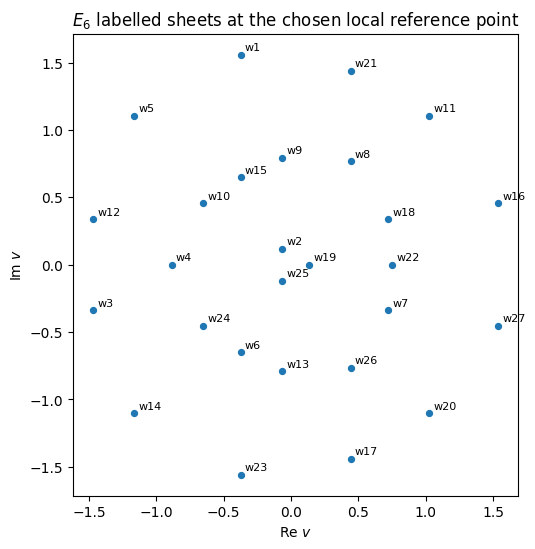

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df_E6_sheets["Re(v)"], df_E6_sheets["Im(v)"], s=18)
for _, row in df_E6_sheets.iterrows():
    ax.annotate(row["weight"], (row["Re(v)"], row["Im(v)"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
ax.set_title(r"$E_6$ labelled sheets at the chosen local reference point")
ax.set_xlabel(r"Re $v$")
ax.set_ylabel(r"Im $v$")
ax.set_aspect("equal", adjustable="box")
plt.show()

## 7. Appendix B

Appendix B used Mathematica `Manipulate` to drag a point in the \(t\)-plane and watch the roots in the \(v\)-plane. The function below gives the same workflow in Jupyter. If `ipywidgets` is not installed, it falls back to a static plot. On GitHub, the static plot is visible; in a live notebook, installing `ipywidgets` makes the locator interactive.

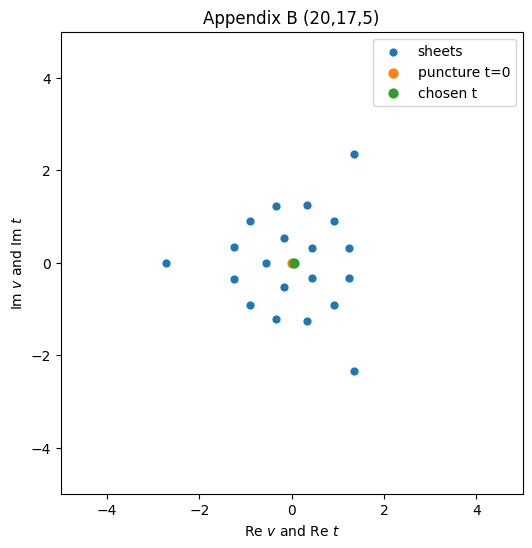

Appendix-B cycle lengths: [3, 5, 12]
Permutation: (1 3 2) (4 9 11 12 15 14 13 10 8 7 6 5) (16 17 19 20 18)


In [12]:
def appendix_B_curve(n1: int = 20, n2: int = 17, n3: int = 5, c1: complex = 1, c2: complex = 1, c3: complex = 0) -> PolynomialCurve:
    """Curve P0(v,t)=(v^n1+c1)t^2 + (v^n2+c2)t + v^n3 + c3."""
    degree = max(n1, n2, n3)

    def coeffs(t: complex) -> np.ndarray:
        c = np.zeros(degree + 1, dtype=np.complex128)
        c[degree - n1] += t**2
        c[-1] += c1 * t**2
        c[degree - n2] += t
        c[-1] += c2 * t
        c[degree - n3] += 1
        c[-1] += c3
        return c

    return PolynomialCurve(coeffs, f"Appendix B ({n1},{n2},{n3})")


def plot_roots_for_t(curve: PolynomialCurve, t: complex, *, plot_range: float = 5.0, ax=None):
    roots = curve.roots(t)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(np.real(roots), np.imag(roots), s=24, label="sheets")
    ax.scatter([0], [0], s=40, label="puncture t=0")
    ax.scatter([np.real(t)], [np.imag(t)], s=40, label="chosen t")
    ax.set_xlim(-plot_range, plot_range)
    ax.set_ylim(-plot_range, plot_range)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"Re $v$ and Re $t$")
    ax.set_ylabel(r"Im $v$ and Im $t$")
    ax.set_title(curve.name)
    ax.legend(loc="upper right")
    return ax


def appendix_B_widget():
    curve = appendix_B_curve()
    try:
        import ipywidgets as widgets
        from IPython.display import display
    except ImportError:
        print("ipywidgets is not installed; showing a static t=1/20 snapshot instead.")
        return plot_roots_for_t(curve, 1 / 20)

    def draw(x=1 / 20, y=0.0):
        fig, ax = plt.subplots(figsize=(6, 6))
        plot_roots_for_t(curve, x + 1j * y, ax=ax)
        plt.show()

    ui = widgets.interactive(
        draw,
        x=widgets.FloatSlider(value=1 / 20, min=-1, max=1, step=0.01, description="Re t"),
        y=widgets.FloatSlider(value=0.0, min=-1, max=1, step=0.01, description="Im t"),
    )
    display(ui)
    return ui

# Static view, plus the monodromy captured by a small loop.
app_curve = appendix_B_curve()
plot_roots_for_t(app_curve, 1 / 20, plot_range=5)
plt.show()

app_track = monodromy_permutation(app_curve, radius=1/20, steps=720)
print("Appendix-B cycle lengths:", sorted([len(c) for c in app_track.cycles]))
print("Permutation:", permutation_summary(app_track.permutation))

def appendix_B_loop_widget(radius=1/20, plot_range=5.0):
    curve = appendix_B_curve()
    try:
        import ipywidgets as widgets
        from IPython.display import display
    except ImportError:
        print("ipywidgets is not installed.")
        return None

    def draw(theta=0.0):
        t = radius * np.exp(1j * theta)

        fig, ax = plt.subplots(figsize=(6, 6))
        plot_roots_for_t(curve, t, plot_range=plot_range, ax=ax)

        # draw the small loop in the t-plane
        angles = np.linspace(0, 2*np.pi, 300)
        loop = radius * np.exp(1j * angles)
        ax.plot(np.real(loop), np.imag(loop), linestyle="--", linewidth=1)

        ax.set_title(rf"{curve.name}: $t={t:.3g}$")
        plt.show()

    ui = widgets.interactive(
        draw,
        theta=widgets.FloatSlider(
            value=0.0,
            min=0.0,
            max=2*np.pi,
            step=0.02,
            description=r"$\theta$"
        )
    )
    display(ui)
    return ui

In [13]:
ui = appendix_B_widget()

interactive(children=(FloatSlider(value=0.05, description='Re t', max=1.0, min=-1.0, step=0.01), FloatSlider(v…

In [19]:
appendix_B_loop_widget(radius=1/20)

interactive(children=(FloatSlider(value=0.0, description='$\\theta$', max=6.283185307179586, step=0.02), Outpu…

interactive(children=(FloatSlider(value=0.0, description='$\\theta$', max=6.283185307179586, step=0.02), Outpu…

## 8. The E-type tables

For the exceptional groups, the relevant monodromies are regular Weyl-group elements of the indicated orders. The matrices below are integer root-lattice matrices. They are enough to compute the monodromy cokernal. For E6 and E7, the trapped part from the IHS computation is combined with \(L^0\) as in Section 10. For E8 the center is trivial, so \(L^0=L^T\).

In [14]:
def matrix(rows: list[list[int]]) -> sp.Matrix:
    return sp.Matrix(rows)

# E6 root basis compatible with the E6 Cartan matrix used above.
E6_MONODROMY = {
    8: matrix([
        [1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, -1],
        [1, 1, 0, 0, 0, -1],
        [0, 1, 1, 0, 0, -1],
        [0, 1, 1, 0, -1, 0],
        [0, 0, 0, 1, -1, 0],
    ]),
    9: matrix([
        [0, 0, -1, 1, 0, 0],
        [1, 0, -1, 1, 0, -1],
        [1, 0, -1, 1, 0, 0],
        [2, 0, -2, 2, -1, 0],
        [1, -1, -1, 2, -1, 0],
        [0, 0, 0, 1, -1, 0],
    ]),
    12: matrix([
        [0, 0, -1, 1, 0, 0],
        [0, -1, 0, 1, 0, 0],
        [1, 0, -1, 1, 0, 0],
        [1, -1, -1, 2, -1, 1],
        [0, 0, 0, 1, -1, 1],
        [0, 0, 0, 1, -1, 0],
    ]),
}

E7_MONODROMY = {
    14: matrix([
        [-1, 0, 1, 0, 0, 0, 0],
        [-1, -1, 1, 1, -1, 0, 1],
        [-2, 0, 1, 1, -1, 0, 1],
        [-2, -1, 1, 2, -2, 1, 1],
        [-1, -1, 0, 2, -1, 0, 1],
        [0, 0, 0, 1, -1, 0, 1],
        [0, 0, 0, 1, -1, 0, 0],
    ]),
    18: matrix([
        [-1, 0, 1, 0, 0, 0, 0],
        [0, -1, 0, 1, 0, 0, 0],
        [-1, 0, 0, 1, 0, 0, 0],
        [-1, -1, 0, 1, 1, 0, 0],
        [-1, -1, 0, 1, 0, 1, 0],
        [-1, -1, 0, 1, 0, 0, 1],
        [-1, -1, 0, 1, 0, 0, 0],
    ]),
}

E8_MONODROMY = {
    20: matrix([
        [0, -1, 0, 1, -1, 1, 0, 0],
        [0, -1, -1, 2, -1, 0, 1, 0],
        [-1, -1, 0, 2, -2, 1, 1, 0],
        [0, -1, -1, 3, -3, 1, 2, 0],
        [0, -1, 0, 2, -2, 0, 2, 0],
        [0, -1, 0, 2, -2, 0, 1, 1],
        [0, 0, 0, 1, -1, 0, 0, 1],
        [0, 0, 0, 1, -1, 0, 0, 0],
    ]),
    24: matrix([
        [-1, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, -1],
        [-1, -1, 1, 1, 0, 0, 0, -1],
        [-1, -1, 2, 0, 1, 0, 0, -2],
        [-1, -1, 2, 0, 1, -1, 1, -2],
        [0, -1, 1, 0, 1, -1, 1, -1],
        [0, -1, 1, 0, 1, -1, 0, 0],
        [0, 0, 0, 0, 1, -1, 0, 0],
    ]),
    30: matrix([
        [-1, 0, 1, 0, 0, 0, 0, 0],
        [0, -1, 0, 1, 0, 0, 0, 0],
        [-1, 0, 0, 1, 0, 0, 0, 0],
        [-1, -1, 0, 1, 1, 0, 0, 0],
        [-1, -1, 0, 1, 0, 1, 0, 0],
        [-1, -1, 0, 1, 0, 0, 1, 0],
        [-1, -1, 0, 1, 0, 0, 0, 1],
        [-1, -1, 0, 1, 0, 0, 0, 0],
    ]),
}

# IHS trapped data for E6/E7, represented as periodic dictionaries in k mod b.
TRAPPED_E6 = {
    8: {4: [2, 2]},
    9: {3: [3, 3], 6: [3, 3]},
    12: {4: [3, 3], 6: [2, 2], 8: [3, 3]},
}
TRAPPED_E7 = {
    14: {7: [2, 2, 2, 2, 2, 2]},
    18: {6: [3, 3], 9: [2, 2, 2, 2, 2, 2], 12: [3, 3]},
}


def group_from_periodic_table(table: dict[int, dict[int, list[int]]], b: int, k: int) -> list[int]:
    kk = k % b
    if kk == 0:
        kk = b
    return list(table.get(b, {}).get(kk, []))


def exceptional_table(monodromy: dict[int, sp.Matrix], trapped: dict[int, dict[int, list[int]]], b: int) -> pd.DataFrame:
    M = monodromy[b]
    rows = {"L_T": [], "L_0": [], "Zhat": [], "W_P": [], "W_T": []}
    for k in range(1, b + 1):
        L0 = defect_group_from_monodromy(M ** k)
        LT = group_from_periodic_table(trapped, b, k)
        HT = square_root_group_factors(LT)
        WT = HT.copy()
        WP = subtract_group_factors(L0, HT)
        Zhat = subtract_group_factors(WP, WT)
        rows["L_T"].append(group_str(LT))
        rows["L_0"].append(group_str(L0))
        rows["Zhat"].append(group_str(Zhat))
        rows["W_P"].append(group_str(WP))
        rows["W_T"].append(group_str(WT))
    return pd.DataFrame(rows, index=range(1, b + 1)).T


def e8_table(b: int) -> pd.DataFrame:
    M = E8_MONODROMY[b]
    row = [group_str(defect_group_from_monodromy(M ** k)) for k in range(1, b + 1)]
    return pd.DataFrame([row], index=[f"b={b}"], columns=range(1, b + 1))

In [15]:
print("E6 tables 8-10")
for b in [8, 9, 12]:
    print(f"\nE6^(b={b})")
    display(exceptional_table(E6_MONODROMY, TRAPPED_E6, b))

E6 tables 8-10

E6^(b=8)


,1,2,3,4,5,6,7,8
L_T,0,0,0,Z2^2,0,0,0,0
L_0,0,0,0,Z2^2,0,0,0,0
Zhat,0,0,0,0,0,0,0,0
W_P,0,0,0,Z2,0,0,0,0
W_T,0,0,0,Z2,0,0,0,0



E6^(b=9)


,1,2,3,4,5,6,7,8,9
L_T,0,0,Z3^2,0,0,Z3^2,0,0,0
L_0,Z3,Z3,Z3^3,Z3,Z3,Z3^3,Z3,Z3,0
Zhat,Z3,Z3,Z3,Z3,Z3,Z3,Z3,Z3,0
W_P,Z3,Z3,Z3^2,Z3,Z3,Z3^2,Z3,Z3,0
W_T,0,0,Z3,0,0,Z3,0,0,0



E6^(b=12)


,1,2,3,4,5,6,7,8,9,10,11,12
L_T,0,0,0,Z3^2,0,Z2^2,0,Z3^2,0,0,0,0
L_0,Z3,Z3,0,Z3^3,Z3,Z2^2,Z3,Z3^3,0,Z3,Z3,0
Zhat,Z3,Z3,0,Z3,Z3,0,Z3,Z3,0,Z3,Z3,0
W_P,Z3,Z3,0,Z3^2,Z3,Z2,Z3,Z3^2,0,Z3,Z3,0
W_T,0,0,0,Z3,0,Z2,0,Z3,0,0,0,0


In [16]:
print("E7 tables 11-12")
for b in [14, 18]:
    print(f"\nE7^(b={b})")
    display(exceptional_table(E7_MONODROMY, TRAPPED_E7, b))

E7 tables 11-12

E7^(b=14)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14
L_T,0,0,0,0,0,0,Z2^6,0,0,0,0,0,0,0
L_0,Z2,0,Z2,0,Z2,0,Z2^7,0,Z2,0,Z2,0,Z2,0
Zhat,Z2,0,Z2,0,Z2,0,Z2,0,Z2,0,Z2,0,Z2,0
W_P,Z2,0,Z2,0,Z2,0,Z2^4,0,Z2,0,Z2,0,Z2,0
W_T,0,0,0,0,0,0,Z2^3,0,0,0,0,0,0,0



E7^(b=18)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
L_T,0,0,0,0,0,Z3^2,0,0,Z2^6,0,0,Z3^2,0,0,0,0,0,0
L_0,Z2,0,Z2,0,Z2,Z3^2,Z2,0,Z2^7,0,Z2,Z3^2,Z2,0,Z2,0,Z2,0
Zhat,Z2,0,Z2,0,Z2,0,Z2,0,Z2,0,Z2,0,Z2,0,Z2,0,Z2,0
W_P,Z2,0,Z2,0,Z2,Z3,Z2,0,Z2^4,0,Z2,Z3,Z2,0,Z2,0,Z2,0
W_T,0,0,0,0,0,Z3,0,0,Z2^3,0,0,Z3,0,0,0,0,0,0


In [17]:
print("E8 table 13: L_T = L_0 because the E8 center is trivial")
for b in [20, 24, 30]:
    print(f"\nE8^(b={b})")
    display(e8_table(b))

E8 table 13: L_T = L_0 because the E8 center is trivial

E8^(b=20)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
b=20,0,0,0,Z5^2,Z2^4,0,0,Z5^2,0,Z2^8,0,Z5^2,0,0,Z2^4,Z5^2,0,0,0,0



E8^(b=24)


,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
b=24,0,0,Z2^2,0,0,Z2^4,0,Z3^4,Z2^2,0,...,Z2^2,Z3^4,0,Z2^4,0,0,Z2^2,0,0,0



E8^(b=30)


,1,2,3,4,5,6,7,8,9,10,...,21,22,23,24,25,26,27,28,29,30
b=30,0,0,0,0,0,Z5^2,0,0,0,Z3^4,...,0,0,0,Z5^2,0,0,0,0,0,0


In [18]:
# Lightweight regression tests against the patterns printed in the paper.
assert exceptional_table(E6_MONODROMY, TRAPPED_E6, 12).loc["L_0", 6] == "Z2^2"
assert exceptional_table(E6_MONODROMY, TRAPPED_E6, 9).loc["W_T", 3] == "Z3"
assert exceptional_table(E7_MONODROMY, TRAPPED_E7, 18).loc["L_0", 9] == "Z2^7"
assert e8_table(30).loc["b=30", 15] == "Z2^8"
print("All table-regression checks passed.")

All table-regression checks passed.


## 9. What to change for a new puncture

For a new local geometry, the only required input is a `PolynomialCurve`. The monodromy pipeline is then:

```python
curve = PolynomialCurve(coeffs=my_coefficients, name="my puncture")
ws = A_weight_system(n)          # or D_weight_system(n), E6_weight_system(), ...
track = choose_local_radius(curve, initial_radius=..., steps=...)
sheet_to_weight = ...            # automatic for A/D/E6 in this notebook
weight_perm = sheet_perm_to_weight_perm(track.permutation, sheet_to_weight)
M = root_matrix_from_weight_permutation(ws, weight_perm)
defect_group_from_monodromy(M)
```

The notebook includes automatic numerical labelling for A/D/E6/E7. For E7 this uses the 56 weights, 28 opposite pairs, and 630 quadruplets. The table reproduction still uses precomputed root-lattice representatives of the regular monodromies because it is faster and avoids re-solving 56-sheet covers in every table cell.